# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [4]:


import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [5]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [6]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy en test: 0.9722
F1 macro en test: 0.971
Accuracy de validacion cruzada (referencia): 0.9791

Reporte por clase:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        12
           1     0.9333    1.0000    0.9655        14
           2     1.0000    0.9000    0.9474        10

    accuracy                         0.9722        36
   macro avg     0.9778    0.9667    0.9710        36
weighted avg     0.9741    0.9722    0.9720        36



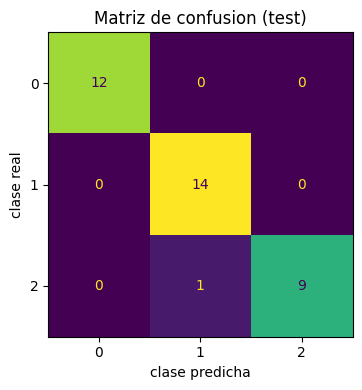

In [10]:
# TODO: calcula predicciones, accuracy y F1 macro
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy en test:", round(accuracy, 4))
print("F1 macro en test:", round(f1_macro, 4))
print("Accuracy de validacion cruzada (referencia):", round(training_metadata["cv_accuracy_mean"], 4))

# TODO: muestra classification_report y matriz de confusión
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Matriz de confusion (test)")
ax.set_xlabel("clase predicha")
ax.set_ylabel("clase real")
plt.tight_layout()
plt.show()


**Análisis:**

> El modelo campeón acierta 35 de los 36 registros de test: **accuracy 0,9722** y **F1 macro 0,9710**.
>
> **¿Es coherente con la validación cruzada?** Sí. La validación cruzada había estimado 0,9791 con una desviación de 0,0277 entre folds. El 0,9722 de test queda apenas 0,7 puntos por debajo, muy dentro de esa desviación, así que la estimación obtenida sin tocar el test se sostuvo al abrirlo. No hay evidencia de sobreajuste: un modelo que hubiera memorizado el entrenamiento habría caído mucho más al enfrentarse a datos nuevos.
>
> **¿Qué clases se confunden?** Hay un único error: un vino de la clase 2 clasificado como clase 1. Las clases 0 y 1 se recuperan completas (recall 1,0000) y la clase 2 pierde uno de sus diez ejemplos (recall 0,9000), lo que a su vez baja la precision de la clase 1 a 0,9333, porque recibió un caso que no le correspondía. Es coherente con el EDA: la clase 0 se separa nítidamente por `proline` y la clase 2 por `flavanoids`, mientras que la clase 1 es la intermedia, de modo que la frontera entre 1 y 2 es la más estrecha de las tres.
>
> **Por qué el F1 macro queda por debajo de la accuracy** (0,9710 frente a 0,9722): el único error cayó en la clase minoritaria, y el promedio macro le asigna el mismo peso que a las demás, mientras que la accuracy lo diluye entre los 36 registros. Es exactamente el comportamiento que motiva usar esta métrica cuando las clases están desbalanceadas.
>
> **Limitación principal.** El conjunto de test tiene solo 36 registros, así que cada acierto o error vale 2,8 puntos de accuracy. El margen de incertidumbre alrededor de 0,9722 es ancho y la diferencia frente a la validación cruzada no debe sobreinterpretarse en ninguna dirección. La conclusión defendible es que el modelo generaliza bien, no que su accuracy sea exactamente 97,22 %.


## 3. Función de inferencia

In [11]:
feature_columns = contract["features"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    # TODO: verifica columnas faltantes
    faltantes = [columna for columna in feature_columns if columna not in records.columns]
    if faltantes:
        raise ValueError(
            f"Faltan {len(faltantes)} columnas exigidas por el contrato de datos: {faltantes}"
        )

    # TODO: ordena las columnas como feature_columns
    # Selecciona por nombre en el orden del contrato y descarta columnas extra.
    entrada = records[feature_columns].copy()

    # TODO: devuelve prediction y probabilidades
    predicciones = model.predict(entrada)
    probabilidades = model.predict_proba(entrada)

    salida = pd.DataFrame(index=records.index)
    salida["prediction"] = predicciones
    for posicion, clase in enumerate(model.classes_):
        salida[f"proba_clase_{clase}"] = probabilidades[:, posicion]
    # Probabilidad de la clase elegida: permite marcar casos dudosos en produccion.
    salida["confianza"] = probabilidades.max(axis=1)

    return salida


# Comprobacion 1: debe fallar con un mensaje claro si falta una columna.
try:
    predict(X_test.drop(columns=["proline"]).head(2))
except ValueError as error:
    print("Validacion de esquema OK ->", error)

# Comprobacion 2: debe funcionar aunque las columnas lleguen desordenadas.
desordenado = X_test.head(3)[list(reversed(feature_columns))]
print("\nCon las columnas en orden invertido:")
print(predict(desordenado).round(4).to_string())


Validacion de esquema OK -> Faltan 1 columnas exigidas por el contrato de datos: ['proline']

Con las columnas en orden invertido:
   prediction  proba_clase_0  proba_clase_1  proba_clase_2  confianza
0           0         0.9997         0.0003         0.0000     0.9997
1           1         0.0071         0.5404         0.4525     0.5404
2           0         0.9920         0.0077         0.0003     0.9920


## 4. Predicción por lotes

In [12]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

# TODO: llama a predict y guarda batch_predictions.csv
predicciones_lote = predict(new_records)

# Se guardan las features junto a las predicciones para que el archivo sea auditable:
# quien lo reciba puede verificar que registro produjo cada resultado.
batch_predictions = pd.concat([new_records, predicciones_lote], axis=1)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)

print("Guardado en:", REPORTS_DIR / "batch_predictions.csv")
print(f"{len(batch_predictions)} registros y {batch_predictions.shape[1]} columnas\n")
print(predicciones_lote.round(4).to_string())

Guardado en: c:\Users\jjdia\Documents\semestre_6\Codigo\IA\Introduction_AI\lecture-6-ml\challenge\reports\batch_predictions.csv
5 registros y 18 columnas

   prediction  proba_clase_0  proba_clase_1  proba_clase_2  confianza
0           0         0.9997         0.0003         0.0000     0.9997
1           1         0.0071         0.5404         0.4525     0.5404
2           0         0.9920         0.0077         0.0003     0.9920
3           1         0.2900         0.7075         0.0026     0.7075
4           1         0.0330         0.9623         0.0047     0.9623


## 5. Reporte final

In [13]:
# TODO: guarda test_metrics.json con modelo, accuracy y F1 macro

test_metrics = {
    "model": training_metadata["champion"],
    "best_params": training_metadata["best_params"],
    "accuracy": float(accuracy),
    "f1_macro": float(f1_macro),
    "n_test": int(len(y_test)),
    # Referencia de validacion cruzada, para poder contrastar sin abrir otro archivo.
    "cv_accuracy_mean": float(training_metadata["cv_accuracy_mean"]),
    "cv_accuracy_std": float(training_metadata["cv_accuracy_std"]),
    "per_class": classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    "confusion_matrix": pd.crosstab(y_test, y_pred).values.tolist(),
    "confusion_matrix_orden": "filas = clase real, columnas = clase predicha",
}

with open(REPORTS_DIR / "test_metrics.json", "w", encoding="utf-8") as archivo:
    json.dump(test_metrics, archivo, indent=2, ensure_ascii=False, default=float)

print("Guardado en:", REPORTS_DIR / "test_metrics.json")
print(f"\nModelo:   {test_metrics['model']}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}  (CV: {test_metrics['cv_accuracy_mean']:.4f})")
print(f"F1 macro: {test_metrics['f1_macro']:.4f}")
print(f"Matriz:   {test_metrics['confusion_matrix']}")


Guardado en: c:\Users\jjdia\Documents\semestre_6\Codigo\IA\Introduction_AI\lecture-6-ml\challenge\reports\test_metrics.json

Modelo:   logistic_regression
Accuracy: 0.9722  (CV: 0.9791)
F1 macro: 0.9710
Matriz:   [[12, 0, 0], [0, 14, 0], [0, 1, 9]]


In [14]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | Regresión logística (`C=1.0`), dentro de un pipeline con imputación por mediana y `StandardScaler` |
| Accuracy CV | 0,9791 (desviación 0,0277 sobre 5 folds estratificados) |
| Accuracy test | 0,9722 — 35 aciertos de 36 |
| F1 macro test | 0,9710 |
| Clases más confundidas | 2 → 1: el único error es un vino de la clase 2 clasificado como clase 1. Las clases 0 y 1 se recuperan completas |
| Principal limitación | El test tiene 36 registros, así que cada error vale 2,8 puntos de accuracy y el margen de incertidumbre es amplio. Además, dos de los cinco registros del lote salieron con confianza por debajo de 0,71, señal de que el modelo acierta pero no siempre con holgura |

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.